In [ ]:
!pip install -q langchain langchain-groq langchain-community langgraph

## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

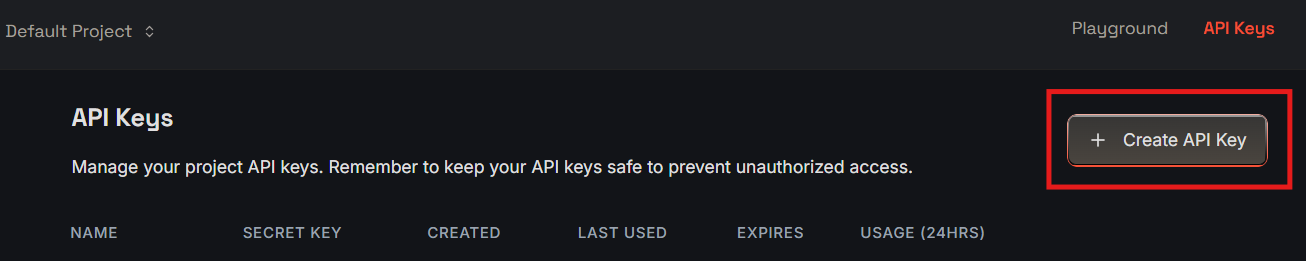

In [ ]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

### **Adding Tools to our Model**

Along with text generation, many models also support:
- Function/Tool Calling
- Structured Output
- Multimodality
- Reasoning

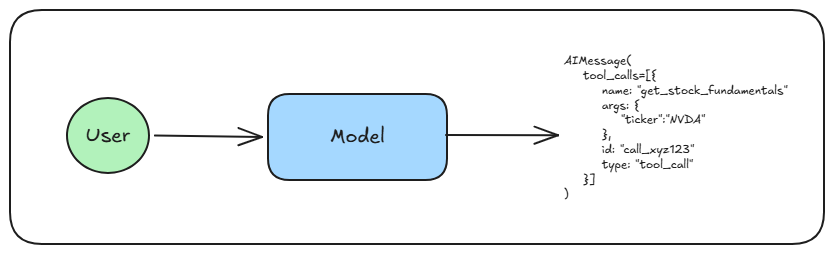

In [ ]:
!pip install -q yfinance

In [ ]:
import yfinance as yf
from langchain.tools import tool

@tool
def get_stock_fundamentals(ticker: str) -> dict:
    """Get current stock price, P/E ratio, market cap, and revenue growth for a ticker."""
    stock = yf.Ticker(ticker)
    info = stock.info
    return {
        "price": info.get("currentPrice"),
        "pe_ratio": info.get("trailingPE"),
        "market_cap": info.get("marketCap"),
        "revenue_growth": info.get("revenueGrowth"),
        "52w_high": info.get("fiftyTwoWeekHigh"),
        "52w_low": info.get("fiftyTwoWeekLow"),
    }

In [ ]:
tool_augmented_model = llm.bind_tools([get_stock_fundamentals])

response = tool_augmented_model.invoke("How is Dhaval patel's company doing?")

print(response)
print(f"{500*'='}\n\n")
for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    tool_result = get_stock_fundamentals.invoke(tool_call)
    print(tool_result.content)

content='I’m not sure which Dhaval\u202fPatel you’re referring to—there are a few people with that name who have founded or co‑founded companies. Could you let me know the company’s name or industry (e.g., fintech, e‑commerce, etc.)? That way I can give you the most accurate update.' additional_kwargs={'reasoning_content': 'The user asks: "How is Dhaval patel\'s company doing?" We need to interpret. Dhaval Patel is a name; could be a founder of a company. We need to identify which company. Possibly Dhaval Patel is a founder of "Kite" or "Zomato"? Actually, Dhaval Patel is a co-founder of "Kite" (a fintech company). But also there is a Dhaval Patel who is a founder of "Kite" (Kite is a fintech startup). There\'s also a Dhaval Patel who is a co-founder of "Kite" (Kite is a fintech startup that offers a trading platform). There\'s also a Dhaval Patel who is a co-founder of "Kite" (Kite is a fintech startup that offers a trading platform). But the user might refer to "Kite" or "Kite" is a 

### **Building Our First Agent**

**_What are we building?_**

A finance research analyst agent that can query stock fundamentals, search through web, reason and help us make financial decisions.

We are going to use the `create_agent` function by langchain that will enable us to build our finance agent without writing tons of code.

REVISION:

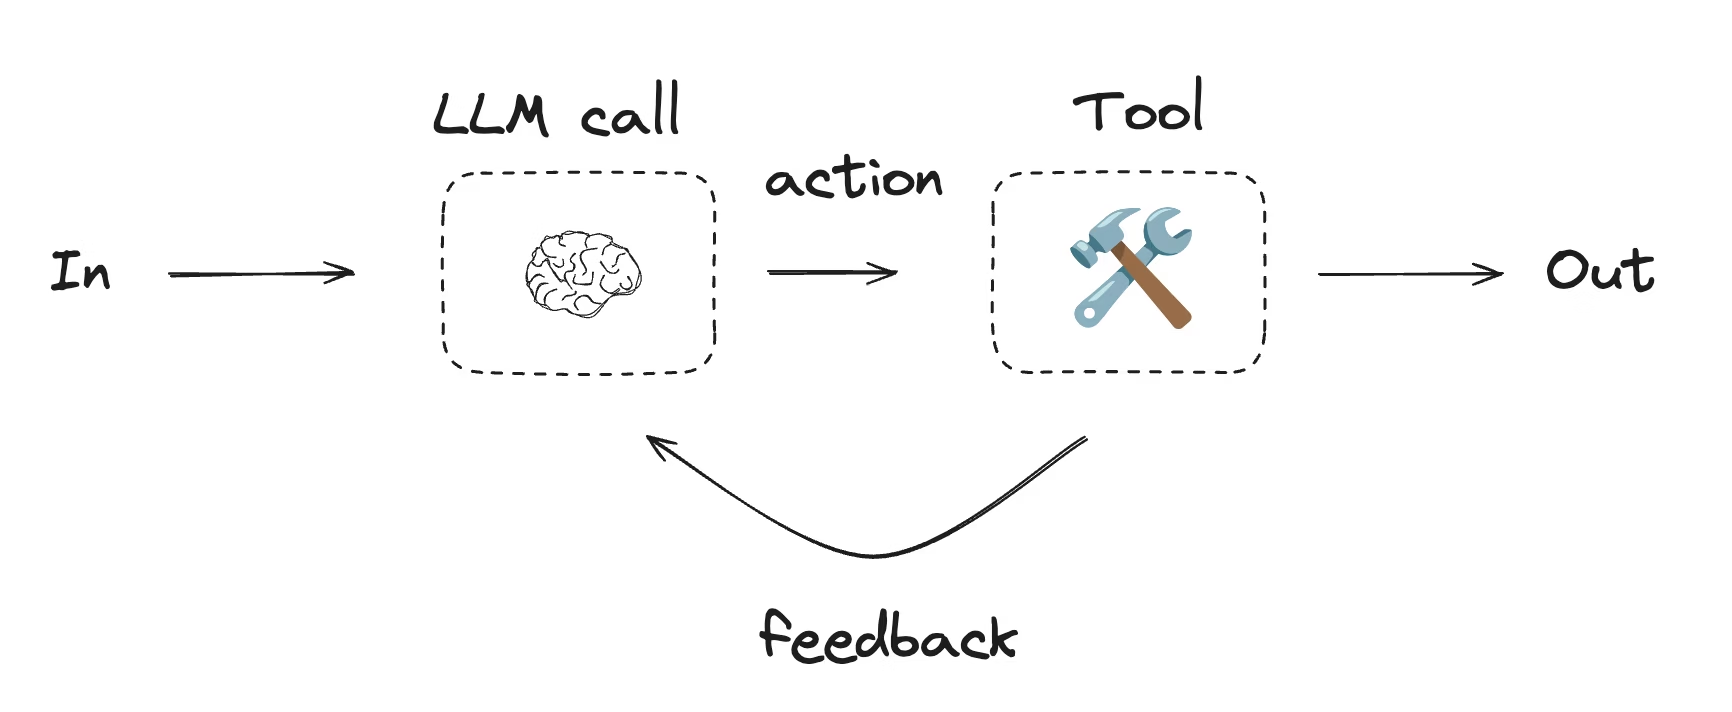


What actions should our Analyst be able to take?

- Search Google & Yahoo news
- Access Yahoo Finance API to get stock fundamentals
- Acesss Wikipedia

In [ ]:
!pip install -q wikipedia google-search-results

### **SerpAPI**

Allows us to query through google search.

**How to access the API KEY?**

1. Go to https://serpapi.com/dashboard
2. Login with email or Google
3. Get access to the dashboad and click on `API Key`
4. Copy it somewhere safe
5. Paste it in the text box

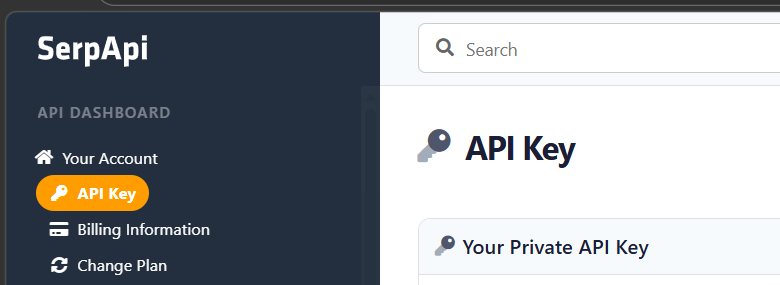

In [ ]:
if "SERPAPI_API_KEY" not in os.environ:
    os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your SerpAPI API key: ")

Enter your SerpAPI API key: ··········


In [ ]:
from langchain_community.utilities import SerpAPIWrapper

serp = SerpAPIWrapper(
    serpapi_api_key=os.getenv("SERPAPI_API_KEY"),
    params={
        "tbm": "nws",     # Search in Google News
        "tbs": "qdr:d",   # Past day (24 hours)
    },
)

@tool
def search_news(query: str) -> str:
    """
    Search last-24h Google News via SerpAPI.
    Returns news results with URLs.
    """
    return serp.run(query)

/tmp/ipykernel_3010/1971957157.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SerpAPIWrapper


In [ ]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool


tools = [
    get_stock_fundamentals,
    YahooFinanceNewsTool(),
    WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()),
    search_news
]

In [ ]:
from langchain.agents import create_agent


SYSTEM_PROMPT = """
You are FinBot, an expert equity research analyst with deep knowledge of financial markets,
valuation methodologies, and macroeconomic trends.

## Task
Given a stock ticker or company name, produce a concise, structured analyst brief that helps users evaluate the investment. Do not give buy/sell advice. Present data-driven signals only.

## Rules
1. Gather data before analysis. Never rely on memory for numbers.
2. If a tool fails or returns empty data, state it and proceed.
3. Never fabricate prices, ratios, or news.
4. Always follow the output format.
5. Flag notable risks or red flags.

## Output Format

**[TICKER] — Analyst Brief**
- 📊 **Fundamentals:** price, P/E, market cap, revenue growth (one line)
- 📈 **Valuation Signal:** OVERVALUED / FAIRLY VALUED / UNDERVALUED + reason
- 📰 **News Sentiment:** bullish / neutral / bearish + key headline
- ⚠️ **Key Risks:** 1–2 bullets
- 🧭 **Outlook:** 1–2 sentence synthesis, no advice
"""

my_finance_agent = create_agent(
    model= llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT
)

In [ ]:
agent_trace = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick analyst brief on NVDA. Is now a good time to buy?"}]}
)

agent_trace

{'messages': [HumanMessage(content='Give me a quick analyst brief on NVDA. Is now a good time to buy?', additional_kwargs={}, response_metadata={}, id='776f9068-99b5-49df-90b7-43a73046ae74'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to produce analyst brief for NVDA. Must gather data: price, P/E, market cap, revenue growth. Use get_stock_fundamentals. Also news sentiment: use yahoo_finance_news or search_news. Let's call get_stock_fundamentals for NVDA.", 'tool_calls': [{'id': 'fc_f20597b7-9a8b-4d5c-8031-475f51ff746c', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 540, 'total_tokens': 627, 'completion_time': 0.087807485, 'completion_tokens_details': {'reasoning_tokens': 59}, 'prompt_time': 0.00325685, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.173482097, 'total_time': 0.091064335}, 'model_name': 'op

In [ ]:
print(agent_trace["messages"][-1].content)

**NVDA — Analyst Brief**  
- 📊 **Fundamentals:** $205.19, P/E ≈ 31.4, market cap ≈ $4.97 T, revenue growth ≈ 85.2% YoY (2025 FY).  
- 📈 **Valuation Signal:** FAIRLY VALUED – the P/E is moderate for a high‑growth AI‑chip leader, and the stock trades at ~86% of its 52‑week high, suggesting room for upside if growth persists.  
- 📰 **News Sentiment:** bullish – multiple recent articles highlight continued AI demand, rising revenue forecasts, and analyst price‑target hikes.  
- ⚠️ **Key Risks:**  
  1. **Valuation pressure** – high P/E relative to peers could tighten if growth slows.  
  2. **Macro & supply constraints** – chip‑manufacturing bottlenecks and broader tech‑sector selloffs could weigh on earnings.  
- 🧭 **Outlook:** Nvidia remains a leading AI‑hardware provider with strong revenue momentum, but valuation and supply‑chain risks temper enthusiasm. The stock’s performance will likely hinge on sustained AI demand and the company’s ability to navigate chip‑production constraints.


In [ ]:
agent_repsp_2 = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Now compare it with AMD"}]}
)

In [ ]:
print(agent_repsp_2["messages"][-1].content)

**AMD — Analyst Brief**  
- 📊 **Fundamentals:** $511.57, P/E 169.4, market cap $834 B, revenue growth 37.8% YoY  
- 📈 **Valuation Signal:** OVERVALUED – P/E far above the semiconductor peer average (~30‑40) and near the 52‑week high, suggesting premium pricing for growth expectations.  
- 📰 **News Sentiment:** bullish – “Citi upgrades AMD to Buy, citing GPU upside and AI opportunities.”  
- ⚠️ **Key Risks:**  
  1. **Valuation pressure** – high P/E may limit upside if growth slows or earnings miss expectations.  
  2. **Competitive intensity** – Nvidia, Intel, and emerging AI‑chip players could erode AMD’s market share in GPUs and data‑center CPUs.  
- 🧭 **Outlook:** AMD continues to benefit from AI and GPU demand, driving strong revenue growth, but its lofty valuation and fierce competition could constrain future upside.


### **Short Term Memory:**
Memory for individual chat session. It tracks the ongoing conversation by maintaining message history within a session.

### **Long Term Memory:**
It's user specific memory and application data across session. It can be recalled at any time and in any thread.


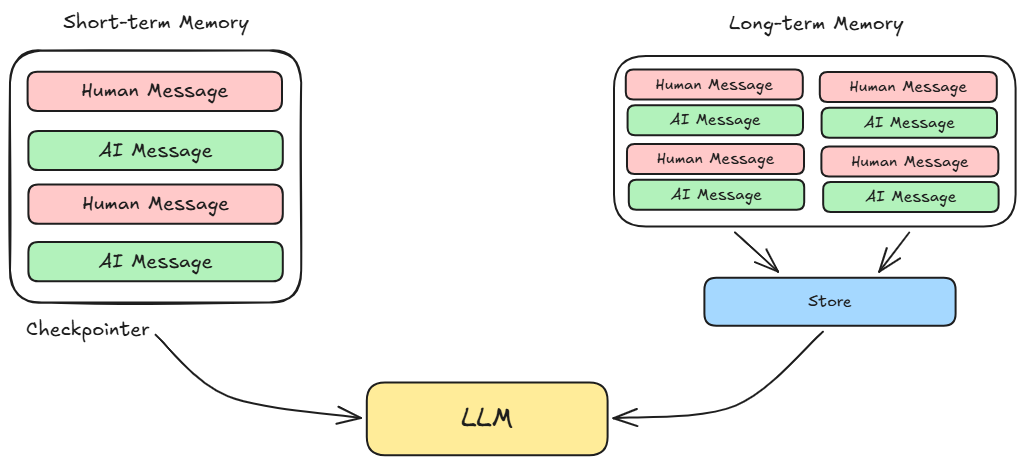

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

my_finance_agent = create_agent(
    model= llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=InMemorySaver()
)

In [ ]:
config = {"configurable": {"thread_id": "user-alice-session-1"}}

In [ ]:
my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick brief on NVDA"}]},
    config
)

{'messages': [HumanMessage(content='Give me a quick brief on NVDA', additional_kwargs={}, response_metadata={}, id='ca63732c-d96a-4cce-a964-3529adfb79f1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to fetch fundamentals for NVDA. Use get_stock_fundamentals. Then news sentiment: use yahoo_finance_news or search_news. Let's get fundamentals.", 'tool_calls': [{'id': 'fc_92af8de1-03b7-4d62-8b60-ebbef0873085', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 530, 'total_tokens': 593, 'completion_time': 0.066294952, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.027362652, 'prompt_tokens_details': None, 'queue_time': 0.202376456, 'total_time': 0.093657604}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None

In [ ]:
my_fin_agent_rep = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "How does it compare to AMD on valuation?"}]},
    config
)

print(my_fin_agent_rep["messages"][-1].content)

**NVDA vs. AMD — Valuation Comparison**  
- 📊 **Fundamentals:**  
  - **NVDA:** $205.19, P/E ≈ 31.4, market cap ≈ $4.97 T, revenue growth ≈ 85.2%  
  - **AMD:** $511.57, P/E ≈ 169.4, market cap ≈ $834 B, revenue growth ≈ 37.8%  
- 📈 **Valuation Signal:**  
  - **NVDA:** FAIRLY VALUED – P/E near the 12‑month semiconductor average; revenue multiple ≈ 1.3×.  
  - **AMD:** OVERVALUED – P/E is 5× the sector average; revenue multiple ≈ 3.5×, driven by high growth expectations that may be harder to sustain.  
- 📰 **News Sentiment:**  
  - **NVDA:** bullish – analysts are raising revenue forecasts and price targets.  
  - **AMD:** mixed – some upgrades but also concerns about margin compression and competitive pressure.  
- ⚠️ **Key Risks:**  
  - **NVDA:** valuation tightening if AI demand slows; supply‑chain constraints.  
  - **AMD:** high P/E may compress if growth slows; exposure to commodity price swings and intense competition.  
- 🧭 **Outlook:** NVDA’s valuation is more aligned with it

In [ ]:
my_fin_agent_rep2 = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Given both, which has better growth prospects?"}]},
    config
)

print(my_fin_agent_rep2["messages"][-1].content)

**Growth Prospects – NVDA vs. AMD**

- **Revenue Growth:**  
  - **NVDA:** 85.2% YoY (2025) – driven by AI‑accelerator, data‑center, and gaming segments.  
  - **AMD:** 37.8% YoY (2025) – driven by CPU/GPUs for PCs, servers, and gaming, but growth is more mature.

- **Catalysts:**  
  - **NVDA:** Rapid expansion of AI workloads, new GPU architectures (Ada Lovelace, Hopper), and strong enterprise adoption.  
  - **AMD:** Continued demand for high‑performance CPUs/GPUs, but growth is increasingly competitive and margin‑sensitive.

- **Conclusion:** **NVDA** shows higher short‑term revenue growth and stronger AI‑related momentum, giving it a more aggressive growth trajectory compared to AMD’s more balanced but slower expansion.


### **Persistent memory Storage: Sqlite**

Use Sqlite to store messages.

In [ ]:
!pip install langgraph-checkpoint-sqlite

In [ ]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn = sqlite3.connect("finance_agent.db", check_same_thread=False)
checkpointer = SqliteSaver(conn)

my_finance_agent_persistent = create_agent(llm,
                                           tools=tools,
                                           system_prompt=SYSTEM_PROMPT,
                                           checkpointer=checkpointer)

In [ ]:
config = {"configurable": {"thread_id": "user-alice-session-1"}}

In [ ]:
my_finance_agent_persistent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick brief on NVDA"}]},
    config
)

{'messages': [HumanMessage(content='Give me a quick brief on NVDA', additional_kwargs={}, response_metadata={}, id='936f4e20-bbc9-404b-bb5f-6062464d43ed'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to fetch fundamentals for NVDA. Use get_stock_fundamentals. Then news sentiment: use yahoo_finance_news or search_news. Let's get fundamentals.", 'tool_calls': [{'id': 'fc_1688cdfd-4bfd-4cd1-97e2-09e8e2e5d382', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 530, 'total_tokens': 593, 'completion_time': 0.068567845, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.035942593, 'prompt_tokens_details': None, 'queue_time': 0.185440894, 'total_time': 0.104510438}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None

In [ ]:
my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "How does it compare to AMD on valuation?"}]},
    config
)

{'messages': [HumanMessage(content='Give me a quick brief on NVDA', additional_kwargs={}, response_metadata={}, id='ca63732c-d96a-4cce-a964-3529adfb79f1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to fetch fundamentals for NVDA. Use get_stock_fundamentals. Then news sentiment: use yahoo_finance_news or search_news. Let's get fundamentals.", 'tool_calls': [{'id': 'fc_92af8de1-03b7-4d62-8b60-ebbef0873085', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 530, 'total_tokens': 593, 'completion_time': 0.066294952, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.027362652, 'prompt_tokens_details': None, 'queue_time': 0.202376456, 'total_time': 0.093657604}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None

In [ ]:
my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Given both, which has better growth prospects?"}]},
    config
)

{'messages': [HumanMessage(content='Give me a quick brief on NVDA', additional_kwargs={}, response_metadata={}, id='ca63732c-d96a-4cce-a964-3529adfb79f1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to fetch fundamentals for NVDA. Use get_stock_fundamentals. Then news sentiment: use yahoo_finance_news or search_news. Let's get fundamentals.", 'tool_calls': [{'id': 'fc_92af8de1-03b7-4d62-8b60-ebbef0873085', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 530, 'total_tokens': 593, 'completion_time': 0.066294952, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.027362652, 'prompt_tokens_details': None, 'queue_time': 0.202376456, 'total_time': 0.093657604}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None

### **Install semantic-router**

In [1]:
!pip install "semantic-router[local]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 MB 15.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 24.2 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.2.85-cp312-cp312-linux_x86_64.whl size=2857641 sha256=ba438dd59a9c4a465161b99ab1fda9ac1eb2d61fbff01f6ce9909b9a59fa3875
  Stored in directory: /root/.cache/pip/wheels/42/f1/e6/4d0838406318e2418da6f876ada9ca684c3475234ce8283e90
Successfully built llama-cpp-python


## **Semantic Router**

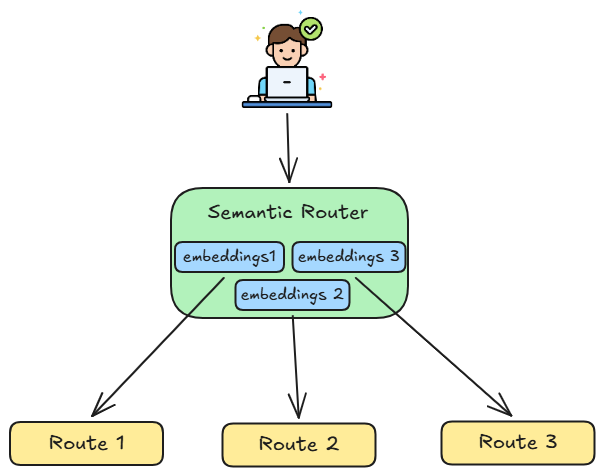



In [2]:
from semantic_router import Route
from semantic_router.routers import SemanticRouter
from semantic_router.encoders import HuggingFaceEncoder

In [3]:
EMBED_MODEL="Qwen/Qwen3-Embedding-0.6B"

In [4]:
from semantic_router.encoders import HuggingFaceEncoder

encoder = HuggingFaceEncoder(name=EMBED_MODEL)

print("Semantic Router encoder ready")
print("Model:", EMBED_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Semantic Router encoder ready
Model: Qwen/Qwen3-Embedding-0.6B


### **Defining Routes**

In [5]:
from semantic_router import Route

stock_analysis_route = Route(
    name="stock_analysis",
    utterances=[
        "What is Apple's P/E ratio?",
        "Show me Tesla's market cap",
        "What are NVIDIA's earnings per share?",
        "How much revenue did Microsoft make last year?",
        "What is Amazon's 52-week high?",
        "Give me the fundamentals for Google stock",
        "What is the current valuation of Meta?",
        "How profitable is JPMorgan?",
        "What's the EPS for Netflix?",
        "Tell me about Berkshire Hathaway's financials",
    ],
)

In [6]:
market_news_route = Route(
    name="market_news",
    utterances=[
        "What is the latest news about Apple?",
        "What happened with Tesla recently?",
        "Any recent announcements from the Fed?",
        "What did the SEC say about crypto this week?",
        "Tell me about recent layoffs in tech",
        "What's happening with the banking sector?",
        "Any earnings surprises this quarter?",
        "What are analysts saying about NVIDIA?",
        "Recent news on interest rate decisions",
        "What happened with the SVB collapse?",
    ],
)

In [7]:
general_finance_route = Route(
    name="general_finance",
    utterances=[
        "What is compound interest?",
        "Explain how the stock market works",
        "What is a P/E ratio?",
        "What is dollar cost averaging?",
        "How do ETFs work?",
        "What is the difference between a stock and a bond?",
        "Explain what inflation means",
        "What is a hedge fund?",
        "How does the Federal Reserve control interest rates?",
        "What is diversification in investing?",
    ],
)

### **Instantiating The Router**

In [8]:
from semantic_router.routers import SemanticRouter

routes = [stock_analysis_route, market_news_route, general_finance_route]

sr = SemanticRouter(
    encoder=encoder,
    routes=routes,
    auto_sync="local",   # store route vectors locally in memory
)

print("SemanticRouter ready")
print(f"Routes: {[r.name for r in routes]}")

2026-06-13 09:48:23 WARNING semantic_router No index provided. Using default LocalIndex.
2026-06-13 09:48:59 WARNING semantic_router No config is written for LocalIndex.


SemanticRouter ready
Routes: ['stock_analysis', 'market_news', 'general_finance']


In [9]:
test_queries = [
    "What is Apple's current P/E ratio?",
    "Tell me about the latest Fed rate decision",
    "How does compound interest work?",
    "Give me NVIDIA's revenue figures",
    "What happened to Silicon Valley Bank?",
    "What is dollar cost averaging?",
    "Can you explain what a hedge fund is?",
]

print("Routing test queries:\n")
for query in test_queries:
    result = sr(query)
    route_name = result.name if result.name else "❌ No route matched"
    print(f"  '{query[:55]}'")
    print(f"   → {route_name}\n")

Routing test queries:

  'What is Apple's current P/E ratio?'
   → general_finance

  'Tell me about the latest Fed rate decision'
   → market_news

  'How does compound interest work?'
   → general_finance

  'Give me NVIDIA's revenue figures'
   → market_news

  'What happened to Silicon Valley Bank?'
   → market_news

  'What is dollar cost averaging?'
   → general_finance

  'Can you explain what a hedge fund is?'
   → general_finance



### **Route Threshold Optimization**

In [10]:
print("Default route thresholds:")
thresholds = sr.get_thresholds()
for route_name, threshold in thresholds.items():
    print(f"  {route_name}: {threshold:.4f}")

Default route thresholds:
  stock_analysis: 0.5000
  market_news: 0.5000
  general_finance: 0.5000


In [11]:
# Training data: (query, expected_route)
train_data = [
    # stock_analysis
    ("What is the P/E ratio for Amazon?",          "stock_analysis"),
    ("Show me TSLA's market cap",                   "stock_analysis"),
    ("How much did Google earn last quarter?",      "stock_analysis"),
    ("What is Microsoft's EPS?",                    "stock_analysis"),
    ("What is the book value of JP Morgan stock?",  "stock_analysis"),
    ("AAPL 52 week high",                           "stock_analysis"),
    ("Tell me NVIDIA's annual revenue",             "stock_analysis"),
    ("Is Berkshire Hathaway overvalued?",           "stock_analysis"),
    ("What's the dividend yield for Coca-Cola?",    "stock_analysis"),
    ("Netflix earnings per share this year",        "stock_analysis"),

    # market_news
    ("What are the latest headlines for Tesla?",    "market_news"),
    ("Did Apple release any news today?",           "market_news"),
    ("What did Jerome Powell say this week?",       "market_news"),
    ("Recent announcements from Amazon",            "market_news"),
    ("What is going on with bank stocks lately?",   "market_news"),
    ("Any SEC filings from Meta recently?",         "market_news"),
    ("Breaking news about the crypto market",       "market_news"),
    ("What happened at the last FOMC meeting?",     "market_news"),
    ("NVIDIA earnings announcement reaction",       "market_news"),
    ("Tech layoffs news 2024",                      "market_news"),

    # general_finance
    ("Can you explain what a mutual fund is?",      "general_finance"),
    ("What does ROI stand for?",                    "general_finance"),
    ("Explain the concept of market liquidity",     "general_finance"),
    ("What is the difference between a Roth and traditional IRA?", "general_finance"),
    ("How do central banks work?",                  "general_finance"),
    ("What is a bear market?",                      "general_finance"),
    ("Explain options trading basics",              "general_finance"),
    ("What is the efficient market hypothesis?",    "general_finance"),
    ("How does inflation affect stock prices?",     "general_finance"),
    ("What is a balance sheet?",                    "general_finance"),

    # None — out of scope, should not match any route
    ("What is the weather in Mumbai tomorrow?",     None),
    ("Write me a poem about the ocean",             None),
    ("Who won the cricket World Cup?",              None),
    ("Recommend a good Italian restaurant",         None),
    ("How do I learn to code in Python?",           None),
]

# Unpack into X (utterances) and y (labels)
X_train, y_train = zip(*train_data)

print(f"Training examples: {len(train_data)}")
print(f"  stock_analysis:  {y_train.count('stock_analysis')}")
print(f"  market_news:     {y_train.count('market_news')}")
print(f"  general_finance: {y_train.count('general_finance')}")
print(f"  None (OOS):      {sum(1 for y in y_train if y is None)}")

Training examples: 35
  stock_analysis:  10
  market_news:     10
  general_finance: 10
  None (OOS):      5


### **Benchmarking Accuracy Before Optimization**

In [12]:
accuracy_before = sr.evaluate(X=list(X_train), y=list(y_train))
print(f"Accuracy BEFORE optimization: {accuracy_before * 100:.2f}%")
print(f"\nDefault thresholds:")
for name, val in sr.get_thresholds().items():
    print(f"  {name}: {val:.4f}")

Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy BEFORE optimization: 68.57%

Default thresholds:
  stock_analysis: 0.5000
  market_news: 0.5000
  general_finance: 0.5000


### **Optimize**

In [13]:
sr.fit(X=list(X_train), y=list(y_train))

print("\nOptimized thresholds:")
for name, val in sr.get_thresholds().items():
    print(f"  {name}: {val:.4f}")

Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Training:   0%|          | 0/500 [00:00<?, ?it/s]


Optimized thresholds:
  stock_analysis: 0.6607
  market_news: 0.6953
  general_finance: 0.2222


In [14]:
accuracy_after = sr.evaluate(X=list(X_train), y=list(y_train))
print(f"Accuracy BEFORE optimization: {accuracy_before * 100:.2f}%")
print(f"Accuracy AFTER  optimization: {accuracy_after  * 100:.2f}%")
print(f"Improvement: +{(accuracy_after - accuracy_before) * 100:.2f}pp")

Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy BEFORE optimization: 68.57%
Accuracy AFTER  optimization: 71.43%
Improvement: +2.86pp


**Testing**

In [15]:
test_data = [
    # stock_analysis — new phrasings
    ("How is Apple stock performing fundamentally?",     "stock_analysis"),
    ("What is Tesla's trailing twelve months revenue?",  "stock_analysis"),
    ("MSFT price to earnings",                           "stock_analysis"),

    # market_news — new phrasings
    ("Any breaking news about interest rates?",          "market_news"),
    ("What did Elon Musk say about Tesla recently?",     "market_news"),
    ("What are traders saying about gold prices?",       "market_news"),

    # general_finance — new phrasings
    ("Explain what short selling means",                 "general_finance"),
    ("What is a stop-loss order?",                       "general_finance"),
    ("How is GDP calculated?",                           "general_finance"),

    # Out of scope
    ("What movies are showing this weekend?",            None),
    ("Give me a recipe for banana bread",                None),
]

X_test, y_test = zip(*test_data)
test_accuracy = sr.evaluate(X=list(X_test), y=list(y_test))
print(f"Test set accuracy (unseen queries): {test_accuracy * 100:.2f}%")

print("\nPer-query results:")
for query, expected in test_data:
    result  = sr(query)
    got     = result.name if result.name else None
    status  = "✅" if got == expected else "❌"
    print(f"  {status} '{query[:50]}'")
    print(f"      expected={expected}  got={got}")

Generating embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Test set accuracy (unseen queries): 72.73%

Per-query results:
  ✅ 'How is Apple stock performing fundamentally?'
      expected=stock_analysis  got=stock_analysis
  ❌ 'What is Tesla's trailing twelve months revenue?'
      expected=stock_analysis  got=market_news
  ✅ 'MSFT price to earnings'
      expected=stock_analysis  got=stock_analysis
  ✅ 'Any breaking news about interest rates?'
      expected=market_news  got=market_news
  ✅ 'What did Elon Musk say about Tesla recently?'
      expected=market_news  got=market_news
  ✅ 'What are traders saying about gold prices?'
      expected=market_news  got=market_news
  ✅ 'Explain what short selling means'
      expected=general_finance  got=general_finance
  ✅ 'What is a stop-loss order?'
      expected=general_finance  got=general_finance
  ❌ 'How is GDP calculated?'
      expected=general_finance  got=stock_analysis
  ✅ 'What movies are showing this weekend?'
      expected=None  got=None
  ❌ 'Give me a recipe for banana bread'
      ex